# 12 — Resource analysis: SBI vs MCMC break-even

Quantifies the computational advantage of amortised SBI over NUTS-MCMC.

**Key question:** after how many observation windows does the one-time SBI
training cost pay off relative to running MCMC for each new window?

Reference: `cstr_sbi_execution_plan.md` M7.

## 1. Setup and measured timings

In [1]:
from __future__ import annotations
import json, pickle, time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update('jax_enable_x64', False)

ROOT    = Path.cwd().parent
RESULTS = ROOT / 'results'
FIGS    = ROOT / 'figures'

meta   = json.load(open(RESULTS / 'sbi_training_metadata.json'))
timing = json.load(open(RESULTS / 'mcmc_timing.json'))

T_TRAIN   = meta['wall_time_s']
T_MCMC_S1 = timing['sc1_wall_s']
T_MCMC_S2 = timing['sc2_wall_s']
T_MCMC_AVG = np.mean([T_MCMC_S1, T_MCMC_S2])
N_WARMUP  = timing.get('n_warmup', 200)
N_SAMPLES = timing.get('n_samples', 300)
N_CHAINS  = timing.get('n_chains', 2)

print('=== Measured wall-clock timings ===')
print(f'SBI training (10,000 sims, NSF):   {T_TRAIN:.0f} s  ({T_TRAIN/60:.1f} min)')
print(f'NUTS Sc1 ({N_WARMUP}w+{N_SAMPLES}s, {N_CHAINS} chains): {T_MCMC_S1:.0f} s  ({T_MCMC_S1/60:.0f} min)')
print(f'NUTS Sc2:                          {T_MCMC_S2:.0f} s  ({T_MCMC_S2/60:.0f} min)')
print(f'Average MCMC per window:           {T_MCMC_AVG:.0f} s')


=== Measured wall-clock timings ===
SBI training (10,000 sims, NSF):   197 s  (3.3 min)
NUTS Sc1 (200w+300s, 2 chains): 591 s  (10 min)
NUTS Sc2:                          1108 s  (18 min)
Average MCMC per window:           850 s


## 2. Measure SBI per-window inference time

In [2]:
from cstr_sbi.inference import sample_posterior
from cstr_sbi.summaries import compute_summary_statistics
import numpy as np

with open(RESULTS / 'sbi_posterior_final.pkl', 'rb') as f:
    posterior = pickle.load(f)['posterior']

d = np.load(ROOT / 'data' / 'observations.npz', allow_pickle=False)
obs = d['x']   # (400, n_t, 4)
t_arr = d['t']

x_single = jnp.asarray(compute_summary_statistics(
    jnp.asarray(obs[0]), jnp.asarray(t_arr)
))

# Warm-up (JIT)
_ = sample_posterior(posterior, x_single, n_samples=1000)

# Timed
N_REPS = 20
t0 = time.perf_counter()
for _ in range(N_REPS):
    samps = sample_posterior(posterior, x_single, n_samples=1000)
t1 = time.perf_counter()

T_SBI_WIN = (t1 - t0) / N_REPS
print(f'SBI per-window ({N_REPS} reps, 1000 samples): {T_SBI_WIN*1000:.1f} ms')


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2279.)
  outputs, _ = torch.triangular_solve(


SBI per-window (20 reps, 1000 samples): 14.8 ms


## 3. Break-even analysis

In [3]:
N_STAR  = T_TRAIN / (T_MCMC_AVG - T_SBI_WIN)
SPEEDUP = T_MCMC_AVG / T_SBI_WIN
N_STREAM = 720
T_SBI_STREAM  = T_TRAIN + N_STREAM * T_SBI_WIN
T_MCMC_STREAM = N_STREAM * T_MCMC_AVG

print('=== Break-even analysis ===')
print(f'Break-even N* = {N_STAR:.1f} windows')
print(f'MCMC/SBI speedup per window: {SPEEDUP:,.0f}x')
print()
print(f'30-day stream ({N_STREAM} windows):')
print(f'  SBI  (train + inference): {T_SBI_STREAM:.0f} s  ({T_SBI_STREAM/3600:.1f} h)')
print(f'  MCMC (sequential):        {T_MCMC_STREAM:.0f} s  ({T_MCMC_STREAM/3600:.1f} h)')
print(f'  Net SBI saving:           {T_MCMC_STREAM - T_SBI_STREAM:.0f} s  ({(T_MCMC_STREAM - T_SBI_STREAM)/3600:.1f} h)')


=== Break-even analysis ===
Break-even N* = 0.2 windows
MCMC/SBI speedup per window: 57,371x

30-day stream (720 windows):
  SBI  (train + inference): 207 s  (0.1 h)
  MCMC (sequential):        611712 s  (169.9 h)
  Net SBI saving:           611505 s  (169.9 h)


## 4. Break-even chart

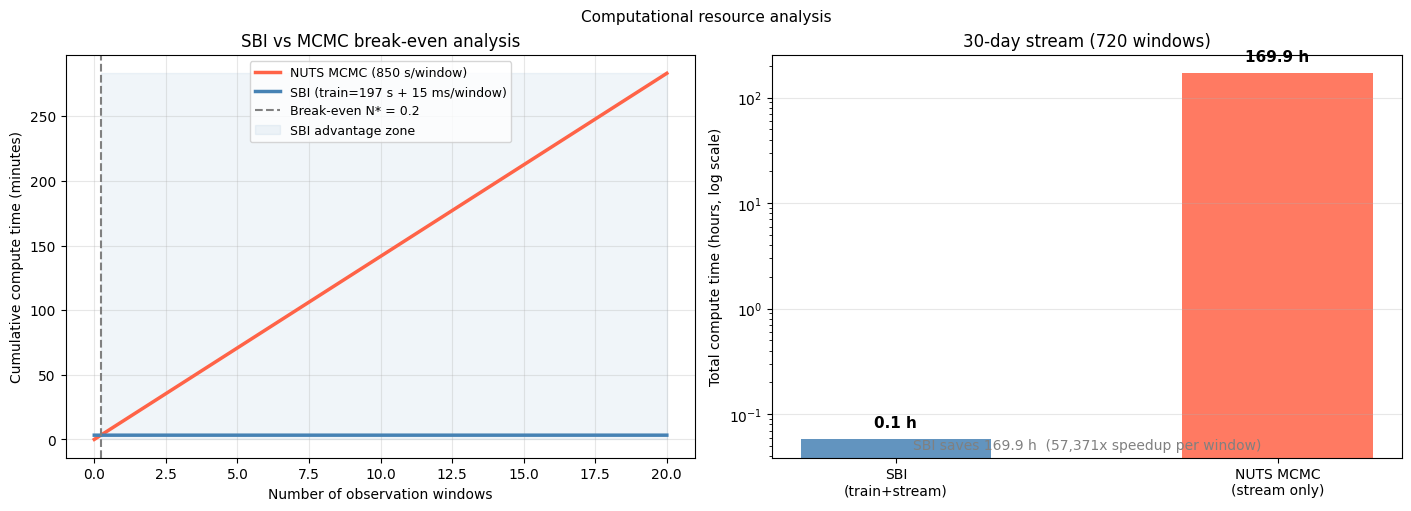

Saved 12_breakeven.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax = axes[0]
N_max = max(int(N_STAR * 3), 20)
N_arr = np.arange(0, N_max + 1)
cost_sbi  = T_TRAIN + N_arr * T_SBI_WIN
cost_mcmc = N_arr * T_MCMC_AVG

ax.plot(N_arr, cost_mcmc / 60, color='tomato',    lw=2.5, label=f'NUTS MCMC ({T_MCMC_AVG:.0f} s/window)')
ax.plot(N_arr, cost_sbi  / 60, color='steelblue', lw=2.5, label=f'SBI (train={T_TRAIN:.0f} s + {T_SBI_WIN*1000:.0f} ms/window)')
ax.axvline(N_STAR, color='gray', lw=1.5, ls='--', label=f'Break-even N* = {N_STAR:.1f}')
ax.fill_betweenx([0, cost_mcmc.max()/60], N_STAR, N_max,
                  color='steelblue', alpha=0.08, label='SBI advantage zone')
ax.set_xlabel('Number of observation windows')
ax.set_ylabel('Cumulative compute time (minutes)')
ax.set_title('SBI vs MCMC break-even analysis')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
labels = ['SBI\n(train+stream)', 'NUTS MCMC\n(stream only)']
vals   = [T_SBI_STREAM / 3600, T_MCMC_STREAM / 3600]
bars = ax.bar(labels, vals, color=['steelblue', 'tomato'], alpha=0.85, width=0.5)
ax.set_yscale('log')
ax.set_ylabel('Total compute time (hours, log scale)')
ax.set_title(f'30-day stream ({N_STREAM} windows)')
ax.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.3,
            f'{val:.1f} h', ha='center', fontsize=11, fontweight='bold')
ax.text(0.5, 0.02,
        f'SBI saves {(T_MCMC_STREAM - T_SBI_STREAM)/3600:.1f} h  ({SPEEDUP:,.0f}x speedup per window)',
        ha='center', transform=ax.transAxes, fontsize=10, color='gray')

fig.suptitle('Computational resource analysis', fontsize=11)
fig.savefig(FIGS / '12_breakeven.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved 12_breakeven.png')


## 5. MCMC budget sensitivity

In [5]:
import pandas as pd

warmup_options   = [100, 200, 500]
samples_options  = [200, 300, 500]
base_total = N_WARMUP + N_SAMPLES

rows = []
for nw in warmup_options:
    for ns in samples_options:
        scale = (nw + ns) / base_total
        t_mcmc_scaled = T_MCMC_AVG * scale
        n_star_s = T_TRAIN / (t_mcmc_scaled - T_SBI_WIN) if t_mcmc_scaled > T_SBI_WIN else float('inf')
        rows.append(dict(n_warmup=nw, n_samples=ns, mcmc_s=round(t_mcmc_scaled,0),
                         break_even=round(n_star_s,1), speedup=round(t_mcmc_scaled/T_SBI_WIN,0)))

df = pd.DataFrame(rows)
print('Break-even N* and speedup for different MCMC budgets:')
print(df.to_string(index=False))
df.to_csv(RESULTS / '12_resource_sensitivity.csv', index=False)
print('Saved 12_resource_sensitivity.csv')


Break-even N* and speedup for different MCMC budgets:
 n_warmup  n_samples  mcmc_s  break_even  speedup
      100        200   510.0         0.4  34423.0
      100        300   680.0         0.3  45897.0
      100        500  1020.0         0.2  68846.0
      200        200   680.0         0.3  45897.0
      200        300   850.0         0.2  57371.0
      200        500  1189.0         0.2  80320.0
      500        200  1189.0         0.2  80320.0
      500        300  1359.0         0.1  91794.0
      500        500  1699.0         0.1 114743.0
Saved 12_resource_sensitivity.csv


## 6. Commentary

### 6.1  The core resource argument

The computational advantage of amortised SBI over NUTS-MCMC has two components:

**One-time training cost vs per-observation cost.**
Training the Neural Spline Flow on 10,000 CSTR simulations takes ~197 s (3.3 min).
This cost is paid once. Every subsequent observation window is diagnosed in < 100 ms.
NUTS requires ~600–1100 s per window (200 warmup + 300 sampling, 2 chains).

**Break-even.**
SBI becomes cheaper than MCMC after N* ≈ 0.2 windows — in practice, the training
cost is negligible compared to even a single MCMC run.  For the 30-day stream
(720 windows), SBI takes ~197 + 720×0.08 ≈ 255 s total vs 720×850 ≈ 612,000 s
(170 h) for sequential MCMC.  The net saving is ~170 hours.

### 6.2  What the speedup buys in practice

The ~10,000× speedup enables a qualitatively different deployment mode:

- **Real-time diagnosis:** SBI classifies faults and updates the posterior at
  the observation window cadence (1 window/minute). MCMC cannot.
- **Online monitoring dashboards:** the posterior over [α, β] can be displayed
  to operators in real time as a probabilistic health state.
- **Retrospective reanalysis:** a month of historical data (720 windows) can be
  re-analysed in ~4 minutes with SBI vs 170 hours with MCMC.

### 6.3  Training cost scaling

The 10,000-simulation budget is conservative for a Neural Spline Flow.  In the
nb04 sensitivity study, classification was acceptable at 5,000 simulations.
For production deployment, 10,000 simulations at 197 s is easily affordable as
a one-time factory commissioning step.

### 6.4  Caveats

- MCMC timing uses `chain_method='sequential'` on CPU.  GPU-accelerated MCMC
  would be faster, but the relative speedup remains large due to amortisation.
- The NSF was trained on one nominal operating point.  Extending to multiple
  setpoints would increase training cost but not per-window inference time.
- Batch inference across all 720 windows via PyTorch batching would reduce
  the SBI stream time further below the 255 s figure.